# 🛰️ GoPilot × Challenge 813
### Ask in one sentence. Get a methane map back.

**Theme 06, Air Quality & Environmental Intelligence.** Below, GoPilot, our geospatial AI agent, takes a single
request, picks the satellite data, runs **MethaneMapper** (our own methane model), and returns map layers, live
in this notebook. Then it does the same for date palms, solar panels and farm fields.

> 👀 **Just reviewing?** Every cell is saved with its output: scroll and watch.
> ▶️ **Running it?** *Run all* works anywhere: without credentials it **replays** our recorded GoPilot
> missions from `results/`. Copy `creds.env.example` to `creds.env`, fill it in, and it flies them **live**.

<a name="1"></a>
## 🎯 1. The problem, and who it is for

**Methane warms about 80 times more than CO₂ over 20 years**, and a small number of oil and gas point sources
emit a large share of it. Many of those sources are in the Arab region. Finding them still means campaigns,
aircraft or a specialist working through satellite data by hand, site by site.

**Sentinel-2 can see many of them for free**: global coverage every 5 days, with two SWIR bands where methane
absorbs. What has been missing is a model that reads that signal reliably, and a way for a non-specialist to use
it.

**Who uses this:**

- **Operators' LDAR and ESG teams**: find and fix leaks before they become a reporting problem.
- **Regulators and environment agencies**: screen many facilities without a field campaign.
- **MRV and carbon verifiers**: an independent, repeatable check on reported emissions.

With GoPilot the request is one sentence, and the answer is a map.

## 🤖 2. Meet GoPilot

**A geospatial AI agent you talk to.** It plans the job, chooses the data and the models, runs them through 93
tools, and hands back map layers. No GIS, no code.

**Already a product:** live in the browser ([app.rasid.ai](https://app.rasid.ai)), in ArcGIS Pro and QGIS, and as
an API, with paying users. RASID has 11 years of Earth-observation work behind it, and GoPilot has been six
years in the making. 🏆 Winner of the AWS GenAI for Geospatial Challenge 2026 (EMEA).

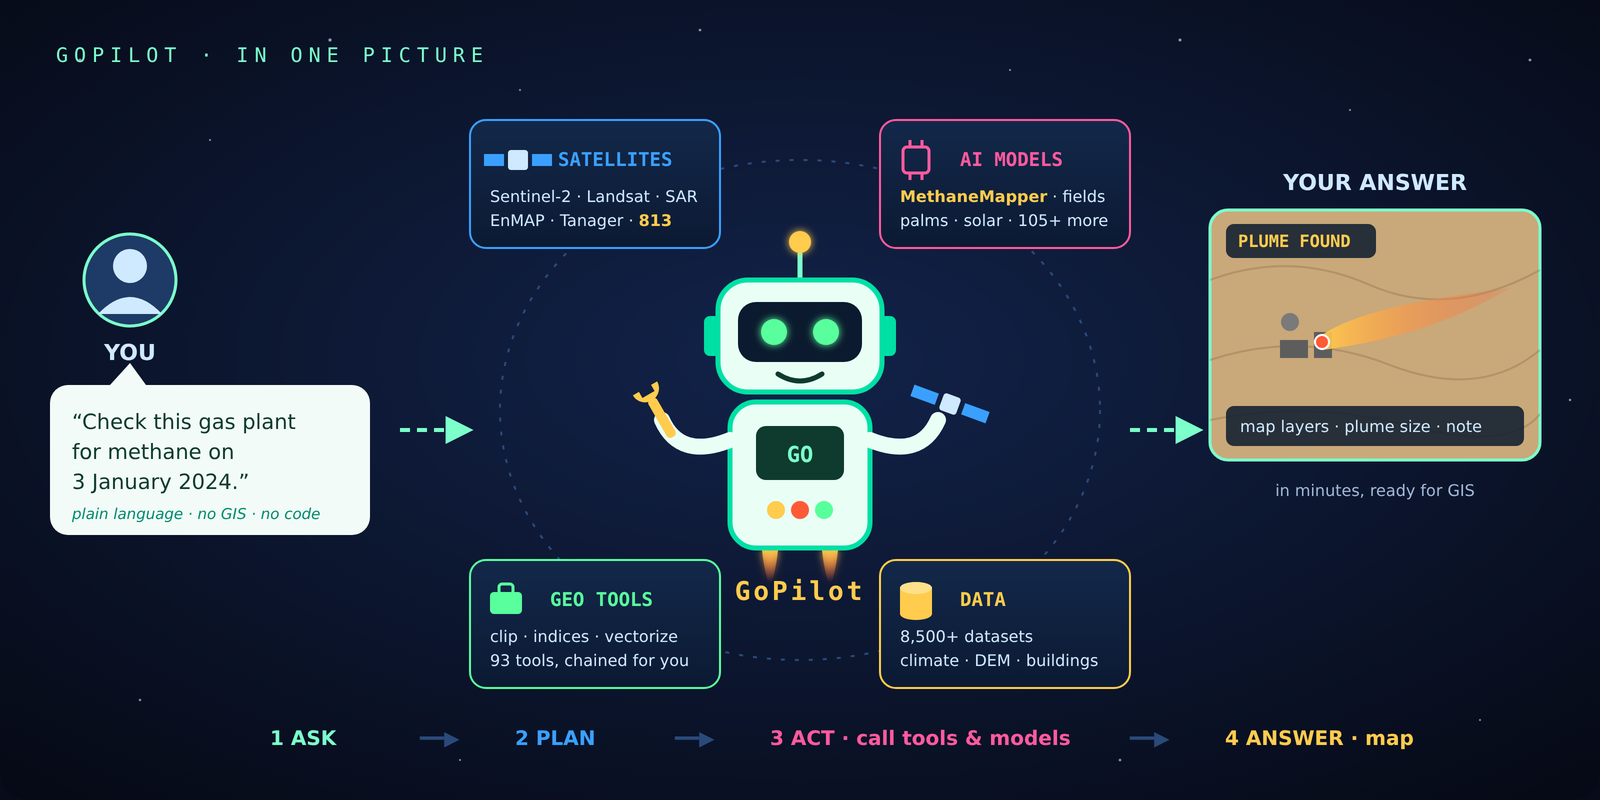

## 🧪 3. MethaneMapper, our methane model

**Ours, end to end:** a six-month project that trained a methane detector **only on physically simulated
plumes**, because real labelled plumes are too few to learn from. It finds **75%+ of confirmed real plumes** in
Sentinel-2.

**Why methane, for 813:** it runs on Sentinel-2 today, and the same physics extends to hyperspectral sensors such
as **Satellite 813**, whose hundreds of narrow bands trace the methane absorption directly.

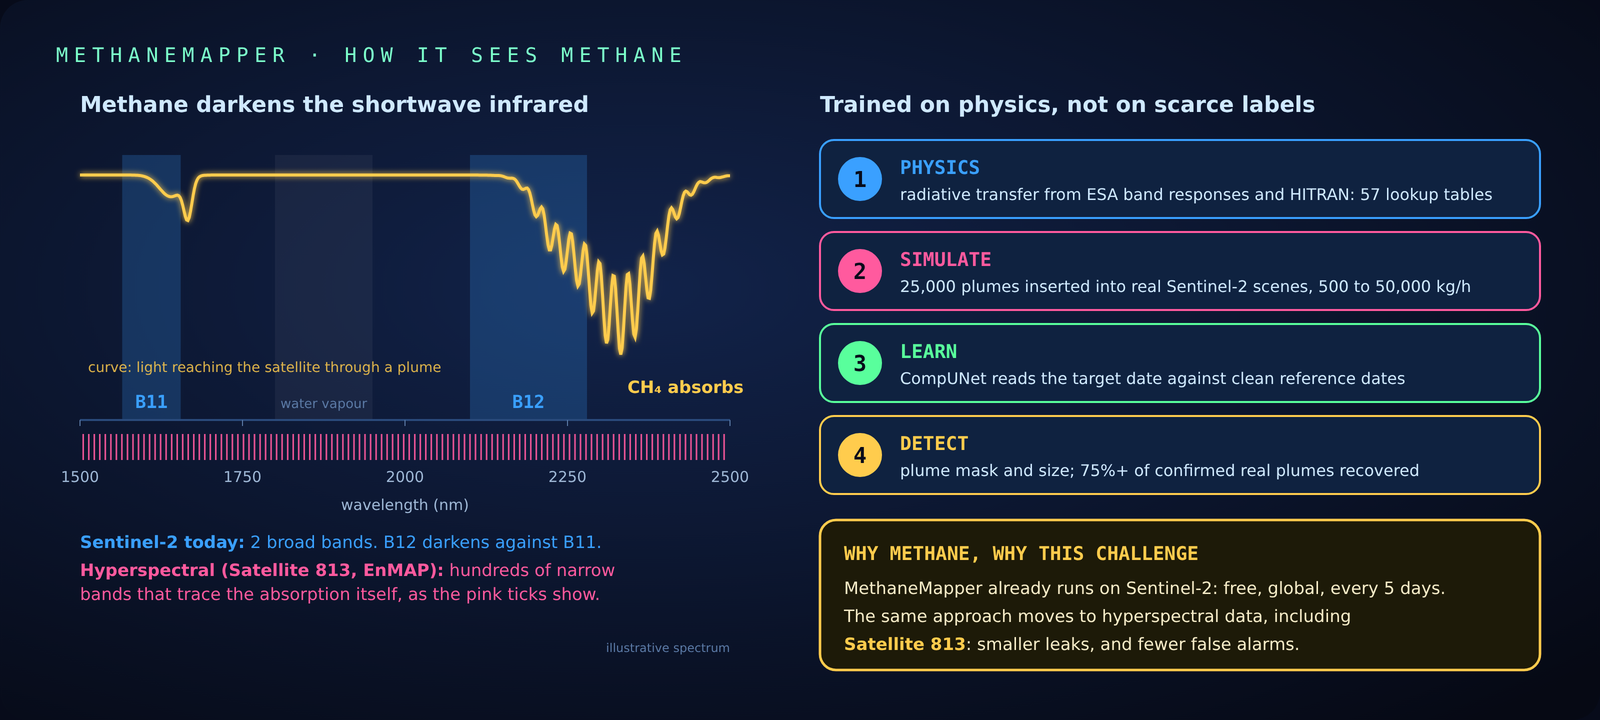

## 🚀 4. Mission 1: methane at a gas plant in Algeria

The **UTGA gas treatment facility at Tabankourt, Algeria**, where MethaneMapper has recorded a plume of about
3,900 kg/h on 3 January 2024. The request names the site, the date and a small box, so the mission stays short.

Run the 🔧 cell once: it loads GoPilot's console from `src/gopilot813/` and says whether this run is live or a replay.

In [ ]:
# @title 🔧 Start GoPilot (run once) { display-mode: "form" }
import pathlib, subprocess, sys

here = pathlib.Path.cwd()
ROOT = next((p for p in [here, *here.parents] if (p / "src" / "gopilot813").is_dir()), None)
if ROOT is None:                          # opened on its own, e.g. in Colab: fetch the repository first
    subprocess.run(["git", "clone", "-q", "--depth", "1",
                    "https://github.com/rasid-ai/gopilot_methane_813_arab_youth.git", "gopilot_813"], check=True)
    ROOT = pathlib.Path("gopilot_813").resolve()
sys.path.insert(0, str(ROOT / "src"))

from gopilot813 import gopilot, show, physics      # the console, the maps and the physics: see src/gopilot813/

### 🎮 Launch

Watch the console: every **quest** is a tool GoPilot calls on its own.

In [ ]:
mission_1 = gopilot.ask("""
    Check the UTGA gas treatment facility at Tabankourt, Algeria (28.64°N, 7.62°E) for methane plumes on
    3 January 2024. Keep the job small: a 4 × 4 km box centred on that point, the Sentinel-2 L1C scene of
    3 January 2024 as the target, and two clean (under 10 % cloud) Sentinel-2 L1C references from the
    60 days before it. Run MethaneMapper and present the plume polygons with their size.
""", mission="mission_1_methane_tabankourt")

### 🗺️ What GoPilot found

The mission postcard below shows on any screen. Under it is the interactive map: zoom in, toggle layers, click a
plume.

In [ ]:
show(mission_1, "TABANKOURT, ALGERIA · 3 JAN 2024 · METHANE")

### 🔬 Why a model? The raw physics, on our sample input
The textbook signal by hand: the change in B12/B11 between 29 Dec 2023 and 3 Jan 2024, on the 4 × 4 km sample in
`data/sample_input/`. Surface changes, like the dry riverbed's edges, light up as brightly as gas would.
Telling the two apart is what MethaneMapper learned from 25,000 simulated plumes.

In [ ]:
frac = physics()

## 🌍 5. Beyond methane

We chose methane as our theme, but GoPilot is not a methane tool. The same one-sentence pattern drives our other
models. Each mission below names a small box and the data to use, so it finishes in a minute or two.

### 🌴 Mission 2: count date palms, Al-Ahsa oasis (Theme 02, agriculture)
Our Saudi palm detector, on a single 30 cm image of a 300 × 300 m farm block.

In [ ]:
mission_2 = gopilot.ask("""
    Count the date palms in this 300 × 300 m block of the Al-Ahsa oasis, Saudi Arabia:
    bbox [49.6105, 25.4205, 49.6135, 25.4235]. Use one Mapbox satellite image of exactly that bbox
    at zoom 19, run the KSA palm detector with its default settings, and present the palm layer.
""", mission="mission_2_palms_alahsa")
show(mission_2, "AL-AHSA OASIS · DATE PALMS")

### ☀️ Mission 3: map solar panels, Dubai (Theme 05, cities and energy)
Our solar-panel model, on a 400 × 400 m block of the Mohammed bin Rashid Al Maktoum Solar Park.

In [ ]:
mission_3 = gopilot.ask("""
    Outline the solar panels in this 400 × 400 m block of the Mohammed bin Rashid Al Maktoum Solar Park,
    Dubai: bbox [55.3630, 24.7520, 55.3670, 24.7560]. Use one Mapbox satellite image of exactly that bbox
    at zoom 19, run the solar-panel model, and present the panel polygons.
""", mission="mission_3_solar_dubai")
show(mission_3, "MBR SOLAR PARK, DUBAI · SOLAR PANELS")

### 🌾 Mission 4: draw farm fields, Wadi Ad-Dawasir (Theme 02, agriculture)
Field boundaries from one Sentinel-2 scene, over a 6 × 6 km box of desert farms.

In [ ]:
mission_4 = gopilot.ask("""
    Delineate the farm fields in this 6 × 6 km box near Wadi Ad-Dawasir, Saudi Arabia:
    bbox [44.700, 20.420, 44.760, 20.480]. Use one clear (under 5 % cloud) Sentinel-2 L2A scene from
    February 2025 as a B04-B03-B02 RGB at 10 m, run the field delineation model at 5 m, and present the fields.
""", mission="mission_4_fields_wadi_addawasir")
show(mission_4, "WADI AD-DAWASIR · FARM FIELDS")

## 📐 6. The fine print

**Method.** GoPilot (Claude on Amazon Bedrock AgentCore) plans each request and calls GoServer, our MCP tool
servers on serverless GPUs. For methane, it compares a Sentinel-2 L1C target scene with clean reference scenes;
MethaneMapper segments plumes from the B12/B11 change.

**Limits, briefly:**

- Sentinel-2's 20 m SWIR sees large point sources (hundreds of kg/h and up), not small leaks.
- Bright, dark or wet surfaces can mimic the signal; a cloudy target date means no detection.
- An agent can choose different reference scenes between runs; the saved run is the one shown.

| Data | Use | Licence |
|---|---|---|
| Copernicus Sentinel-2 L1C / L2A (ESA), via Element84 Earth Search | Methane and field missions | Free and open. *Contains modified Copernicus Sentinel data.* |
| Mapbox Satellite | Palm and solar missions | © Mapbox, © Maxar, used through GoPilot |
| Esri World Imagery | Basemaps here | © Esri, with attribution on the maps |
| GoPilot, MethaneMapper and our models | Detection and orchestration | RASID, used as a service |

**Run it yourself:** *Run all* replays the recorded missions with no setup. To fly them live, copy
`creds.env.example` to `creds.env` and fill in `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY` and `GOPILOT_AGENT_ARN`
(sent with our submission), or set them as environment variables or Colab Secrets. They belong to a GoPilot-only IAM
user that RASID can revoke at any time.

**Team RASID** · [rasid.ai](https://www.rasid.ai) · [app.rasid.ai](https://app.rasid.ai) · info@rasid.ai